In [1]:
!pip install databento

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 14.0 MB/s  0:00:00

   ---------- -----------------------------  3/11 [multidict]
   --------------------- ------------------  6/11 [aiohappyeyeballs]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   -------------------------------- -------  9/11 [aiohttp]
   ------------------------------------ --- 10/11 [databento]
   ------------------------------------ --- 10/11 [databento]
   ------------------------------------ --- 10/11 [databento]
   ---------------------------------------- 11/11 [databento]



In [4]:
import databento as db

API_KEY="db-D5D5jxkLQbcGxG7ESJ3CDxxuNje9U"

client = db.Historical(
    API_KEY
)

In [ ]:

datasets = client.metadata.list_datasets()

for d in datasets:
    print(d)

ARCX.PILLAR
BATS.PITCH
BATY.PITCH
DBEQ.BASIC
EDGA.PITCH
EDGX.PITCH
EPRL.DOM
EQUS.MINI
EQUS.SUMMARY
GLBX.MDP3
IEXG.TOPS
IFEU.IMPACT
IFLL.IMPACT
IFUS.IMPACT
MEMX.MEMOIR
NDEX.IMPACT
OCEA.MEMOIR
OPRA.PILLAR
XASE.PILLAR
XBOS.ITCH
XCBF.PITCH
XCHI.PILLAR
XCIS.TRADESBBO
XEEE.EOBI
XEUR.EOBI
XNAS.BASIC
XNAS.ITCH
XNYS.PILLAR
XPSX.ITCH


In [ ]:
data = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    symbols="GC.FUT",
    schema="ohlcv-1m",
    start="2026-01-01",
    end="2026-01-02"
)

df = data.to_df()

df.head()

"""
========================================
Understanding the Databento Symbol Error
========================================

 The API connection is working correctly.

 The problem is **not** authentication or GLBX.MDP3 access.

 The issue is the **symbol format**.

====================================
Error 1
====================================


 No data found for the request you submitted.


 Meaning:

 Databento searched for:


 GC.FUT


but did not find a matching instrument for the request parameters.

====================================
Error 2 (Important)
====================================


 The symbols GC.FUT match the parent format (ROOT.FUT/OPT/SPOT);
 use stype_in=parent.


 This tells us:

 • `GC.FUT` is a **parent symbol**.
 • It is **not** an actual tradable futures contract.
 • Databento recognizes the symbol format but requires it to be requested as a parent symbol.

====================================
Understanding Futures Symbols
====================================

 Unlike stocks:

 Stock:


 AAPL


 A stock represents one company with one ticker.

 Futures work differently because each contract has an expiration month.

 Example:

 Root Symbol:


 GC


 Actual tradable contracts:


 GCQ6

 GCZ6

 GCV6


 Where:

 • `GC` = Gold Futures.
 • `Q` = August expiration.
 • `Z` = December expiration.
 • `6` = Year 2026.

====================================
Your Example
====================================

Your previous screenshots showed:


 GCQ2026


 This represents:

 • Gold Futures.
 • August 2026 contract.

 Unlike stocks, futures are identified by both:

 • The root symbol.
 • The expiration month and year.

 Each expiration month is a separate tradable contract.

"""

C:\Users\loydt\AppData\Local\Temp\ipykernel_24984\1680186670.py:1: BentoWarning: No data found for the request you submitted.
  data = client.timeseries.get_range(
C:\Users\loydt\AppData\Local\Temp\ipykernel_24984\1680186670.py:1: BentoWarning: The streaming request had one or more symbols which did not resolve: GC.FUT. The symbols GC.FUT match the parent format (ROOT.FUT/OPT/SPOT); use stype_in=parent.
  data = client.timeseries.get_range(


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,


In [5]:
data = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    symbols="GCQ6",
    schema="ohlcv-1m",
    start="2026-01-01",
    end="2026-01-02"
)

df = data.to_df()

df

,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2026-01-01 23:15:00+00:00,33,1,42011464,4440.5,4440.5,4440.5,4440.5,2,GCQ6
2026-01-01 23:52:00+00:00,33,1,42011464,4456.3,4456.3,4456.3,4456.3,1,GCQ6


In [9]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2 entries, 2026-01-01 23:15:00+00:00 to 2026-01-01 23:52:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rtype          2 non-null      uint8  
 1   publisher_id   2 non-null      uint16 
 2   instrument_id  2 non-null      uint32 
 3   open           2 non-null      float64
 4   high           2 non-null      float64
 5   low            2 non-null      float64
 6   close          2 non-null      float64
 7   volume         2 non-null      uint64 
 8   symbol         2 non-null      str    
dtypes: float64(4), str(1), uint16(1), uint32(1), uint64(1), uint8(1)
memory usage: 134.0 bytes


In [10]:
print(df)

                           rtype  publisher_id  instrument_id    open    high  \
ts_event                                                                        
2026-01-01 23:15:00+00:00     33             1       42011464  4440.5  4440.5   
2026-01-01 23:52:00+00:00     33             1       42011464  4456.3  4456.3   

                              low   close  volume symbol  
ts_event                                                  
2026-01-01 23:15:00+00:00  4440.5  4440.5       2   GCQ6  
2026-01-01 23:52:00+00:00  4456.3  4456.3       1   GCQ6  


In [6]:
data = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    symbols="GC.FUT",
    stype_in="parent",
    schema="ohlcv-1m",
    start="2026-01-06",
    end="2026-01-07",
)

df = data.to_df()

print(df.shape)
print(df.head())
print(df.tail())

"""
======================================
Understanding the Returned Instruments
======================================

What you're seeing is **not** one continuous Gold Futures price series.

Instead, you're seeing **every instrument** that matched the parent symbol:

```text
GC.FUT
```

Examples:

```text
GCG6
GCJ6
GCG7
GCG6-GCJ6
GCG6-GCG7
```

These are different financial instruments.

====================================
Decoding the Symbols
====================================

## GCG6

```text
GC = Gold Futures
G  = February
6  = 2026
```

This is an actual Gold Futures contract.

## GCJ6

```text
GC = Gold Futures
J  = April
6  = 2026
```

Another Gold Futures contract with a different expiration month.

## GCG7

```text
GC = Gold Futures
G  = February
7  = 2027
```

A Gold Futures contract for the following year.

====================================
Calendar Spreads
====================================

Example:

```text
GCG6-GCJ6
```

This is **not** a futures contract.

It is a **calendar spread**.

Meaning:

• Long GCG6.
• Short GCJ6.

Mathematically:

```text
Front Contract

−

Next Contract
```

Example price:

```text
-32.5
```

Negative prices are perfectly normal because this represents the **price difference between two contracts**, not the outright price of Gold.

====================================
What Happened?
====================================

When you requested:

```python
symbols="GC.FUT"
stype_in="parent"
```

Databento interpreted the request as:

> "Return every instrument belonging to the Gold Futures product family."

That includes:

• Outright futures contracts.
• Calendar spreads.
• Potentially other related instruments.

====================================
Why This Is Actually Good
====================================

This behavior shows that Databento exposes the **entire product family**, not just the active contract.

This provides flexibility for:

• Futures research.
• Calendar spread analysis.
• Term structure analysis.
• Contract roll studies.

====================================
Our Research Goal
====================================

For our trading research, we **do not** want every instrument.

We want **one clean price series**.

Specifically:

```text
Front-Month Gold Futures
```

because that is typically what discretionary futures traders are watching.

====================================
Step 1 — Inspect Returned Symbols
====================================

Before filtering, inspect every instrument returned:

```python
sorted(df["symbol"].unique())
```

This displays every symbol contained in the dataset.

====================================
Step 2 — Count Each Instrument
====================================

Determine how much data exists for each symbol:

```python
df["symbol"].value_counts()
```

Example output:

```text
GCG6            1400
GCJ6             900
GCM6             700
...
GCG6-GCJ6        300
...
```

====================================
Step 3 — Isolate One Contract
====================================

Example:

```python
gc = df[df["symbol"] == "GCG6"].copy()

print(gc.shape)
gc.head()
```

This produces a clean OHLCV dataset for a single futures contract.

====================================
Architectural Lesson
====================================

Initially, it is tempting to think:

```text
GC.FUT

↓

One Continuous Market
```

However, Databento's parent symbols actually represent an entire instrument family:


GC.FUT
      |
      +-- GCG6
      |
      +-- GCJ6
      |
      +-- GCM6
      |
      +-- GCG7
      |
      +-- GCG6-GCJ6
      |
      +-- GCG6-GCG7
      |
      +-- ...


Therefore:

• `GC.FUT` is **not** a continuous futures contract.
• `GC.FUT` is a **family of related instruments**.

====================================
Implications for Our Research Pipeline
====================================

Rather than requesting `GC.FUT` and immediately analyzing the data, we first need to decide which representation best matches our research objective.

Possible choices:

• Specific Contract (e.g., `GCG6`)
  • Simplest approach.
  • Ideal for learning.
  • Cleanest dataset.

• Front-Month Continuous Contract
  • Better for long-term historical testing.
  • Automatically transitions to the active contract.

• Roll-Adjusted Continuous Series
  • Best for multi-year quantitative research.
  • Requires understanding contract rolls and price adjustments.

====================================
Recommended Starting Point
====================================

Since we're reverse-engineering a discretionary trader who trades the active futures contract, the recommended progression is:

• Start with a single active contract (e.g., `GCG6`).
• Learn the data structure and feature engineering.
• Validate statistical ideas on one contract.
• Progress to continuous contracts.
• Finally, study contract roll methodology for long-term research.

This keeps the research pipeline simple while closely matching how many discretionary futures traders actually analyze and trade the market.
"""

(5447, 9)
                           rtype  publisher_id  instrument_id    open    high  \
ts_event                                                                        
2026-01-06 00:00:00+00:00     33             1       42001025  4450.6  4451.1   
2026-01-06 00:00:00+00:00     33             1       42031409   -32.5   -32.5   
2026-01-06 00:01:00+00:00     33             1       42031409   -32.5   -32.5   
2026-01-06 00:01:00+00:00     33             1       42039347   -65.1   -65.1   
2026-01-06 00:01:00+00:00     33             1          19181  4512.5  4512.5   

                              low   close  volume     symbol  
ts_event                                                      
2026-01-06 00:00:00+00:00  4447.0  4449.0     146       GCG6  
2026-01-06 00:00:00+00:00   -32.5   -32.5       4  GCG6-GCJ6  
2026-01-06 00:01:00+00:00   -32.6   -32.6       2  GCG6-GCJ6  
2026-01-06 00:01:00+00:00   -65.1   -65.1       1  GCG6-GCM6  
2026-01-06 00:01:00+00:00  4512.5  4512.5   

'\n======================================\nUnderstanding the Returned Instruments\n======================================\n\nWhat you\'re seeing is **not** one continuous Gold Futures price series.\n\nInstead, you\'re seeing **every instrument** that matched the parent symbol:\n\n```text\nGC.FUT\n```\n\nExamples:\n\n```text\nGCG6\nGCJ6\nGCG7\nGCG6-GCJ6\nGCG6-GCG7\n```\n\nThese are different financial instruments.\n\n====================================\nDecoding the Symbols\n====================================\n\n## GCG6\n\n```text\nGC = Gold Futures\nG  = February\n6  = 2026\n```\n\nThis is an actual Gold Futures contract.\n\n## GCJ6\n\n```text\nGC = Gold Futures\nJ  = April\n6  = 2026\n```\n\nAnother Gold Futures contract with a different expiration month.\n\n## GCG7\n\n```text\nGC = Gold Futures\nG  = February\n7  = 2027\n```\n\nA Gold Futures contract for the following year.\n\n====================================\nCalendar Spreads\n====================================\n\nExample:

In [12]:
# ==================================
# Phase 1 — Understand the Universe
# ==================================

 # Our first task is to answer:

 # What exactly did Databento return?

 # Let's inspect the universe of instruments.


symbols = (
    df.groupby("symbol")
      .size()
      .sort_values(ascending=False)
)

print(symbols)

# This tells us:

 # Which contracts exist
 # Which spreads exist
 # Which are the most active

symbol
GCG6         1380
GCG6-GCJ6     812
GCJ6          656
GCH6          347
GCG6-GCH6     340
GCG6-GCM6     319
GCM6          251
GCJ6-GCM6     155
GCG6-GCZ6     134
GCG6-GCQ6     124
GCM6-GCQ6     109
GCQ6-GCV6     103
GCV6-GCZ6      97
GCZ6           79
GCM6-GCZ6      67
GCG6-GCV6      50
GCQ6-GCZ6      46
GCH6-GCJ6      42
GCF6-GCG6      38
GCN6           30
GCQ6           28
GCG6-GCN6      26
GCF6-GCH6      20
GCV6           20
GCM6-GCN6      17
GCG6-GCX6      15
GCV6-GCX6      14
GCM6-GCV6      14
GCX6-GCZ6      10
GCJ6-GCQ6      10
GCJ6-GCZ6       9
GCZ6-GCG7       9
GCN6-GCQ6       9
GCJ6-GCV6       7
GCF6            7
GCK6            5
GCK6-GCM6       5
GCQ6-GCU6       5
GCG6-GCK6       4
GCG7-GCJ7       4
GCG6-GCG7       3
GCJ6-GCN6       3
GCJ6-GCK6       3
GCZ6-GCF7       2
GCQ7            2
GCG7            2
GCM7-GCQ7       2
GCG6-GCM7       2
GCF7            1
GCG6-GCF7       1
GCG6-GCJ7       1
GCH6-GCM6       1
GCG6-GCU6       1
GCJ7-GCM7       1
GCJ7            1
GCU

In [13]:
# Phase 2 — Understand Each Instrument

 # Let's create a data dictionary.

summary = (
    df.groupby("symbol")
      .agg(
          rows=("symbol", "size"),
          first=("open", "first"),
          last=("close", "last"),
          volume=("volume", "sum"),
      )
      .sort_values("volume", ascending=False)
)

summary

# This immediately tells us:

 # Active contract
 # Total traded volume
 # Number of bars

,rows,first,last,volume
symbol,,,,
GCG6,1380,4450.6,4504.6,151688
GCG6-GCJ6,812,-32.5,-32.9,15449
GCJ6,656,4480.5,4538.4,3898
GCG6-GCM6,319,-65.1,-66.1,1558
GCG6-GCH6,340,-16.1,-16.3,1464
GCH6,347,4464.1,4523.4,1388
GCJ6-GCM6,155,-32.7,-33.1,1276
GCM6,251,4512.5,4577.2,616
GCM6-GCQ6,109,-33.0,-33.1,519


In [7]:
# Phase 3 — Separate Futures from Spreads

# Notice:

 # GCG6
 # GCJ6
 # GCG7

# are futures.

# But

# GCG6-GCJ6

# GCG6-GCG7

# are spreads.

# Let's classify them.

contracts = df[~df["symbol"].str.contains("-")].copy()

spreads = df[df["symbol"].str.contains("-")].copy()

In [15]:
contracts["symbol"].unique()

<ArrowStringArray>
['GCG6', 'GCJ6', 'GCM6', 'GCH6', 'GCQ6', 'GCJ7', 'GCZ6', 'GCN6', 'GCF6',
 'GCX6', 'GCV6', 'GCK6', 'GCQ7', 'GCF7', 'GCU6', 'GCG7']
Length: 16, dtype: str

In [16]:
spreads["symbol"].unique()

<ArrowStringArray>
['GCG6-GCJ6', 'GCG6-GCM6', 'GCG6-GCH6', 'GCG6-GCQ6', 'GCH6-GCJ6', 'GCG6-GCV6',
 'GCQ6-GCV6', 'GCJ6-GCM6', 'GCG6-GCZ6', 'GCQ6-GCZ6', 'GCZ6-GCG7', 'GCG6-GCJ7',
 'GCG7-GCJ7', 'GCK6-GCM6', 'GCM6-GCN6', 'GCG6-GCN6', 'GCM6-GCV6', 'GCV6-GCZ6',
 'GCN6-GCQ6', 'GCF6-GCG6', 'GCJ6-GCV6', 'GCM6-GCQ6', 'GCQ6-GCU6', 'GCG6-GCX6',
 'GCG6-GCK6', 'GCJ6-GCZ6', 'GCJ6-GCK6', 'GCJ6-GCN6', 'GCJ6-GCQ6', 'GCM6-GCZ6',
 'GCV6-GCX6', 'GCF6-GCH6', 'GCM7-GCQ7', 'GCX6-GCZ6', 'GCZ6-GCF7', 'GCU6-GCZ6',
 'GCG6-GCG7', 'GCG6-GCF7', 'GCG6-GCM7', 'GCG6-GCU6', 'GCQ6-GCX6', 'GCJ7-GCM7',
 'GCH6-GCM6']
Length: 43, dtype: str

In [17]:
# Phase 4 — Volume Ranking

# This is extremely important.

contracts.groupby("symbol")["volume"] \
         .sum() \
         .sort_values(ascending=False)

# This tells us:

 # Which contract is the market actually trading?

 # Usually the largest volume is the front month.

 # That is probably the contract the YouTuber is trading.

symbol
GCG6    151688
GCJ6      3898
GCH6      1388
GCM6       616
GCZ6       173
GCQ6        76
GCN6        53
GCV6        30
GCF6        15
GCK6         6
GCG7         2
GCQ7         2
GCJ7         1
GCF7         1
GCU6         1
GCX6         1
Name: volume, dtype: uint64

In [ ]:
"""
====================================
Observations from the Returned Data
====================================

====================================
Observation 1 — GC.FUT Is a Product Family
====================================

Our initial assumption was:

```text
GC.FUT

↓

One Continuous Gold Futures Series
```

The data disproves that assumption.

Instead:


GC.FUT
    │
    ├── Individual Futures Contracts
    │     ├── GCF6
    │     ├── GCG6
    │     ├── GCH6
    │     ├── GCJ6
    │     ├── GCK6
    │     ├── GCM6
    │     ├── GCN6
    │     ├── GCQ6
    │     ├── GCU6
    │     ├── GCV6
    │     ├── GCX6
    │     └── GCZ6
    │
    └── Calendar Spreads
          ├── GCG6-GCJ6
          ├── GCG6-GCH6
          ├── GCG6-GCM6
          └── ...


Key takeaway:

• `GC.FUT` is not a single instrument.
• `GC.FUT` is a container representing the entire Gold Futures product family.
• It includes both outright futures contracts and related spread instruments.

====================================
Observation 2 — Volume Reveals the Active Contract
====================================

The most important observation comes from trading volume.

| Contract | Volume       |
|----------|-------------:|
| GCG6     | 151,688      |
| GCJ6     | 3,898        |
| GCH6     | 1,388        |
| GCM6     | 616          |
| Others   | Much Smaller |

The difference is substantial.

```text
GCG6

151,688

↓

GCJ6

3,898
```

GCG6 traded approximately **39×** the volume of GCJ6 in the sampled data.

This strongly suggests:

• GCG6 is the front-month contract.
• GCG6 is the most actively traded contract during this period.
• GCG6 is likely the contract most discretionary traders are watching.

====================================
Observation 3 — Why Multiple Contracts Exist
====================================

Each futures contract represents a different delivery month.

An analogy:

```text
Airline Tickets

February

April

June

August

December
```

All flights go to the same destination.

The only difference is the departure date.

Gold Futures work similarly.

Each contract represents:

• The same underlying commodity.
• A different expiration or delivery month.

====================================
Observation 4 — Calendar Spreads Are Separate Markets
====================================

Example:

```text
GCG6-GCJ6
```

This is **not** the price of Gold.

It is an independent tradable instrument.

Its value represents:

```text
Price(GCG6)

−

Price(GCJ6)
```

This explains values such as:

```text
-32.5
```

Negative prices are normal because they represent the price difference between two futures contracts rather than the outright price of Gold.

Key observations:

 • Calendar spreads have their own market.
 • They have their own liquidity.
 • They have their own price movements.
 • Many professional traders specialize exclusively in trading spreads.

====================================
Observation 5 — Databento Provides Raw Exchange Data
====================================

This is exactly what we want for quantitative research.

Databento is not simplifying or hiding the exchange structure.

Instead, it exposes the market as it actually exists.


 CME Exchange

    ↓

 Product Family

    ↓

 Individual Contracts

    ↓

 Calendar Spreads

    ↓

 Trades

    ↓

 OHLCV Data


This is characteristic of a professional-grade market data provider.

====================================
Key Takeaways
====================================

• `GC.FUT` represents a product family rather than a single futures contract.
• Individual contracts (e.g., GCG6, GCJ6, GCQ6) correspond to different expiration months.
• Trading volume helps identify the active (front-month) contract.
• Calendar spreads are independent tradable instruments with prices based on differences between contracts.
• Databento exposes the raw structure of the CME futures market, making it well suited for professional research and quantitative analysis.
"""

In [ ]:
"""
====================================
Research Decision
====================================

For reverse-engineering Socrates' trading strategy, we will **ignore calendar spreads** during the initial research phase.

Our objective is to study the behavior of the actively traded Gold Futures contract rather than the relationships between contracts.

Create a dataset containing only outright futures contracts:

```python
contracts = (
    df[~df["symbol"].str.contains("-")]
        .copy()
)
```

Then isolate the dominant (front-month) contract:

```python
gc = (
    contracts[contracts["symbol"] == "GCG6"]
        .sort_index()
        .copy()
)
```

This dataset becomes the foundation for our research.

Everything we build initially will use this single contract, including:

• Session reference levels.
• Previous highs and lows.
• Market reactions.
• Statistical analysis.
• Feature engineering.
• Strategy validation.

====================================
A Better Mental Model
====================================

Our understanding of the futures market should be updated.

Instead of thinking:

```text
GC.FUT

↓

One Continuous Gold Futures Series
```

Think of it as:

```text
Exchange (CME)
        │
        ▼
Product
(Gold Futures)
        │
        ▼
Contract Family
(GC.FUT)
        │
        ├── GCF6
        ├── GCG6   ← Active Contract
        ├── GCH6
        ├── GCJ6
        ├── ...
        │
        └── Calendar Spreads
              ├── GCG6-GCJ6
              ├── GCG6-GCH6
              └── ...
```

This hierarchy more accurately represents how the exchange organizes futures instruments.

====================================
What We've Accomplished
====================================

We've effectively completed the **Market Discovery Phase**.

We now understand:

• How Databento organizes futures products.
• The difference between a product family and an individual futures contract.
• How to distinguish outright contracts from calendar spreads.
• How to identify the active (front-month) contract using trading volume.

====================================
Research Pipeline Going Forward
====================================

With the market structure understood, the next stage of research becomes:


 Market Discovery

       ↓

 Select Active Contract

       ↓

 Clean Research Dataset

       ↓

 Feature Engineering

       ↓

 Market Structure Analysis

       ↓

 Statistical Testing

       ↓

 Strategy Validation


This provides a solid foundation for reverse-engineering the trading strategy using a clean, well-defined dataset that reflects the same market being analyzed by discretionary futures traders.
"""

In [18]:
# ==========================================
# Build Research Dataset
# ==========================================

# Keep only outright futures contracts
contracts = (
    df.loc[~df["symbol"].str.contains("-")]
      .copy()
)

# Select the active contract
gc = (
    contracts.loc[contracts["symbol"] == "GCG6"]
             .sort_index()
             .copy()
)

print(gc.shape)
gc.head()

(1380, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2026-01-06 00:00:00+00:00,33,1,42001025,4450.6,4451.1,4447.0,4449.0,146,GCG6
2026-01-06 00:01:00+00:00,33,1,42001025,4449.1,4449.5,4446.5,4447.5,126,GCG6
2026-01-06 00:02:00+00:00,33,1,42001025,4448.0,4449.4,4447.4,4448.5,70,GCG6
2026-01-06 00:03:00+00:00,33,1,42001025,4447.9,4449.1,4447.5,4449.1,41,GCG6
2026-01-06 00:04:00+00:00,33,1,42001025,4449.2,4450.6,4448.2,4450.6,132,GCG6


In [19]:
# ==========================================
# Dataset Overview
# ==========================================

print(gc.info())

print("\n")

print(gc.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 1380 entries, 2026-01-06 00:00:00+00:00 to 2026-01-06 23:59:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rtype          1380 non-null   uint8  
 1   publisher_id   1380 non-null   uint16 
 2   instrument_id  1380 non-null   uint32 
 3   open           1380 non-null   float64
 4   high           1380 non-null   float64
 5   low            1380 non-null   float64
 6   close          1380 non-null   float64
 7   volume         1380 non-null   uint64 
 8   symbol         1380 non-null   str    
dtypes: float64(4), str(1), uint16(1), uint32(1), uint64(1), uint8(1)
memory usage: 90.5 KB
None


        rtype  publisher_id  instrument_id         open         high  \
count  1380.0        1380.0         1380.0  1380.000000  1380.000000   
mean     33.0           1.0     42001025.0  4479.103841  4480.005290   
std       0.0           0.0            0.0    16.507916   

In [20]:
# ==========================================
# Missing Values
# ==========================================

gc.isna().sum()

rtype            0
publisher_id     0
instrument_id    0
open             0
high             0
low              0
close            0
volume           0
symbol           0
dtype: int64

In [21]:
# ==========================================
# Time Range
# ==========================================

print("Start :", gc.index.min())
print("End   :", gc.index.max())

Start : 2026-01-06 00:00:00+00:00
End   : 2026-01-06 23:59:00+00:00


In [22]:
# ==========================================
# Trading Activity
# ==========================================

print("Bars          :", len(gc))
print("Total Volume  :", gc["volume"].sum())
print("Average Volume:", gc["volume"].mean())

Bars          : 1380
Total Volume  : 151688
Average Volume: 109.91884057971015


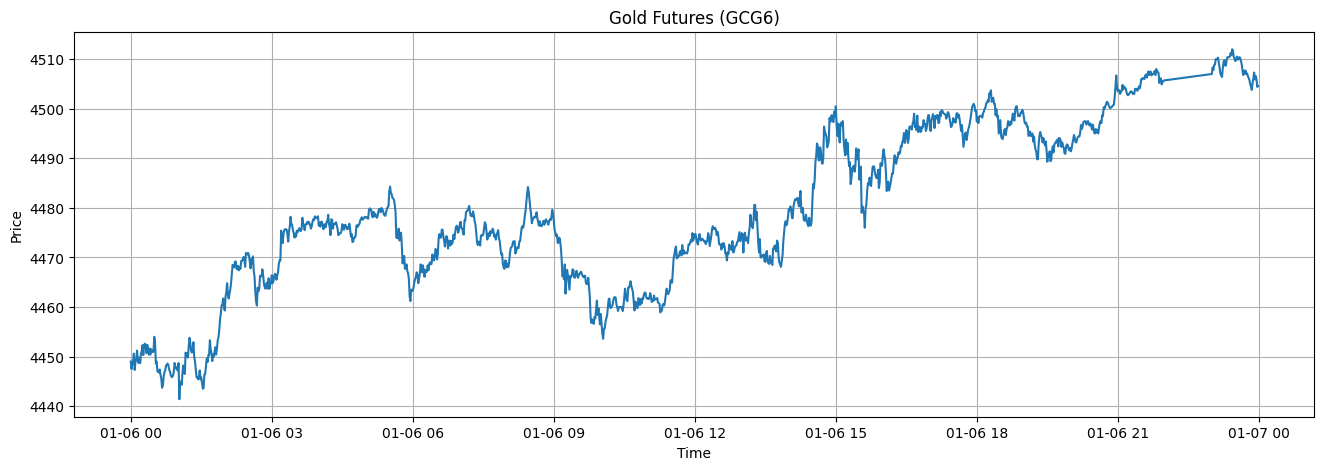

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))
plt.plot(gc.index, gc["close"])
plt.title("Gold Futures (GCG6)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid(True)

plt.show()

In [ ]:
"""
====================================
Dataset Quality Assessment
====================================

====================================
1. No Missing Data ✅
====================================

Missing values:

```text
0
0
0
0
0
0
0
0
0
```

Assessment:

• No missing values were found.
• No data imputation is required.
• No cleaning is required for this sample.
• The dataset is suitable for feature engineering and statistical analysis.

====================================
2. One-Minute OHLCV Data ✅
====================================

The dataset contains:

• Open.
• High.
• Low.
• Close.
• Volume.

Total observations:

```text
1,380 one-minute bars
```

Assessment:

• Represents nearly a full trading day.
• Consistent with an almost 24-hour futures market.
• Brief gaps are expected due to scheduled CME maintenance periods.

====================================
3. Time Coverage ✅
====================================

Dataset coverage:

```text
Start

2026-01-06 00:00 UTC

↓

End

2026-01-06 23:59 UTC
```

Assessment:

• The dataset covers a single trading day.

This immediately reveals an important limitation.

The following reference levels **cannot** be computed from this dataset alone:

• Previous Day High.
• Previous Day Low.
• Previous Day Close.
• Previous 4-Hour High (before midnight).
• Previous 4-Hour Low (before midnight).
• Weekly Open.
• Monthly Open.

These require historical data from earlier trading sessions.

====================================
4. Market Statistics
====================================

Average minute volume:

```text
≈110 contracts per minute
```

Maximum observed volume:

```text
1,157 contracts
```

Interpretation:

• Trading activity varies significantly throughout the day.
• Volume spikes likely occur around:
  • Market opens.
  • Major economic releases.
  • High-impact news events.

Future research can examine whether these periods coincide with Socrates' trade entries.

====================================
5. Price Range
====================================

Daily Low:

```text
4437.9
```

Daily High:

```text
4512.4
```

Daily Range:

```text
4512.4 − 4437.9

=

74.5 points
```

Gold Futures (GC) specifications:

• Contract multiplier = 100 troy ounces.
• One-point move = $100 per contract.

Therefore:

```text
74.5 points

×

$100

=

$7,450 per contract
```

For a trader holding five contracts:

```text
74.5

×

100

×

5

=

$37,250
```

Interpretation:

• Even a single trading day can produce substantial price movement.
• This highlights why disciplined risk management is essential in futures trading.

====================================
The Most Important Discovery
====================================

The key realization is:

> One trading day is **not sufficient** to reconstruct Socrates' trading strategy.

The strategy depends on historical context, including:

• Previous Day High.
• Previous Day Low.
• Previous Day Close.
• Previous 4-Hour High.
• Previous 4-Hour Low.
• Asia Session levels.
• London Session levels.
• New York Session levels.
• Weekly context.

These features require data extending beyond a single day.

====================================
Next Data Requirement
====================================

Rather than downloading another isolated trading day, the recommended approach is to acquire a continuous historical window.

Recommended duration:

```text
30 Days
```

This provides sufficient history to compute:

• Previous Day High.
• Previous Day Low.
• Previous Day Close.
• Previous 4-Hour High.
• Previous 4-Hour Low.
• Weekly Open.
• Monthly Open.
• Session statistics.

With approximately one month of one-minute data, every observation has enough historical context for feature engineering without introducing look-ahead bias.

====================================
Research Roadmap
====================================

```text
Phase 1
Acquire Clean OHLCV Data
                ✅

↓

Phase 2
Acquire Sufficient Historical Context
(Approximately 30 Days)

↓

Phase 3
Engineer Market Reference Levels

    • Daily Open
    • Previous Day High
    • Previous Day Low
    • Previous Day Close
    • Previous 4H High
    • Previous 4H Low
    • Asia Open / High / Low
    • London Open / High / Low
    • New York Open / High / Low
    • Weekly Open
    • Monthly Open

↓

Phase 4
Reverse-Engineer Socrates' Entries

↓

Phase 5
Statistically Test Whether These Reference Levels Produce Meaningful Market Reactions
```

====================================
Research Principle
====================================

Rather than immediately building indicators, the priority is ensuring that the dataset contains the same historical information that would have been available to the trader at each point in time.

This sequence:

• Builds a clean research foundation.
• Prevents look-ahead bias.
• Produces realistic market features.
• Makes subsequent statistical testing more rigorous.
• Improves confidence in any conclusions drawn from the analysis.
"""

In [24]:
# Find the most active outright contract
active_contract = (
    contracts.groupby("symbol")["volume"]
             .sum()
             .idxmax()
)

print(f"Active contract: {active_contract}")

gc = (
    contracts.loc[contracts["symbol"] == active_contract]
             .sort_index()
             .copy()
)

"""
====================================
Research Target Identified
====================================

The downloaded data indicates that, during this period, the market was primarily trading the **February 2026 Gold Futures contract (GCG6)**.

This provides a clear and well-defined target for our research.

====================================
Current Research Dataset
====================================


  Exchange
      CME

          ↓

  Product
      Gold Futures (GC)

          ↓

  Active Contract
      GCG6

          ↓

  Resolution
      1-Minute OHLCV

          ↓

  1,380 Bars


====================================
Research Foundation
====================================

This dataset becomes the foundation for reverse-engineering the trading strategy.

All initial analysis will be based on this active contract, including:

• Session reference levels.
• Previous highs and lows.
• Market structure analysis.
• Price reaction analysis.
• Feature engineering.
• Statistical testing.
• Strategy validation.

By focusing on the actively traded contract, we ensure that our research reflects the same market being observed by discretionary futures traders.
"""

Active contract: GCG6


In [25]:
# ==========================================
# Extract the Active Contract (GCG6)
# ==========================================

gc = (
    df.loc[
        (~df["symbol"].str.contains("-")) &
        (df["symbol"] == "GCG6")
    ]
    .sort_index()
    .copy()
)

print(f"Shape: {gc.shape}")
gc.head()

Shape: (1380, 9)


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2026-01-06 00:00:00+00:00,33,1,42001025,4450.6,4451.1,4447.0,4449.0,146,GCG6
2026-01-06 00:01:00+00:00,33,1,42001025,4449.1,4449.5,4446.5,4447.5,126,GCG6
2026-01-06 00:02:00+00:00,33,1,42001025,4448.0,4449.4,4447.4,4448.5,70,GCG6
2026-01-06 00:03:00+00:00,33,1,42001025,4447.9,4449.1,4447.5,4449.1,41,GCG6
2026-01-06 00:04:00+00:00,33,1,42001025,4449.2,4450.6,4448.2,4450.6,132,GCG6


In [26]:
print(gc["symbol"].unique())

<ArrowStringArray>
['GCG6']
Length: 1, dtype: str


In [27]:
print(gc.info())

print("\nTime Range")
print("--------------------")
print(gc.index.min())
print(gc.index.max())

print("\nTotal Volume")
print("--------------------")
print(gc["volume"].sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 1380 entries, 2026-01-06 00:00:00+00:00 to 2026-01-06 23:59:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rtype          1380 non-null   uint8  
 1   publisher_id   1380 non-null   uint16 
 2   instrument_id  1380 non-null   uint32 
 3   open           1380 non-null   float64
 4   high           1380 non-null   float64
 5   low            1380 non-null   float64
 6   close          1380 non-null   float64
 7   volume         1380 non-null   uint64 
 8   symbol         1380 non-null   str    
dtypes: float64(4), str(1), uint16(1), uint32(1), uint64(1), uint8(1)
memory usage: 90.5 KB
None

Time Range
--------------------
2026-01-06 00:00:00+00:00
2026-01-06 23:59:00+00:00

Total Volume
--------------------
151688


In [8]:
from databento import Historical

client = Historical(API_KEY)
 
df = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    schema="ohlcv-1m",
    symbols="GC.FUT",
    stype_in="parent",
    start="2026-01-01",
    end="2026-07-19",   # end is exclusive, so use the next day
).to_df()

C:\Users\loydt\AppData\Local\Temp\ipykernel_17544\2811632680.py:5: BentoWarning: The streaming request contained one or more days which have reduced quality: 2026-02-14 (missing), 2026-02-21 (missing), 2026-02-28 (missing)... See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  df = client.timeseries.get_range(


In [32]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 819529 entries, 2026-01-01 23:00:00+00:00 to 2026-07-17 20:59:00+00:00
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   rtype          819529 non-null  uint8  
 1   publisher_id   819529 non-null  uint16 
 2   instrument_id  819529 non-null  uint32 
 3   open           819529 non-null  float64
 4   high           819529 non-null  float64
 5   low            819529 non-null  float64
 6   close          819529 non-null  float64
 7   volume         819529 non-null  uint64 
 8   symbol         819529 non-null  str    
dtypes: float64(4), str(1), uint16(1), uint32(1), uint64(1), uint8(1)
memory usage: 54.2 MB


In [33]:
print(df.index.min())
print(df.index.max())

print(df.shape)

print(df["symbol"].nunique())

2026-01-01 23:00:00+00:00
2026-07-17 20:59:00+00:00
(819529, 9)
251


In [34]:
daily_counts = (
    df.groupby(df.index.date)
      .size()
      .rename("rows")
)

print(daily_counts)

2026-01-01     213
2026-01-02    4686
2026-01-04     337
2026-01-05    6018
2026-01-06    5447
              ... 
2026-07-13    5854
2026-07-14    5884
2026-07-15    4924
2026-07-16    4803
2026-07-17    4664
Name: rows, Length: 169, dtype: int64


In [35]:
import pandas as pd

available = pd.to_datetime(daily_counts.index)

expected = pd.date_range(
    available.min(),
    available.max(),
    freq="D",
    tz="UTC"
)

missing = expected.difference(available)

print(missing)

DatetimeIndex(['2026-01-01 00:00:00+00:00', '2026-01-02 00:00:00+00:00',
               '2026-01-03 00:00:00+00:00', '2026-01-04 00:00:00+00:00',
               '2026-01-05 00:00:00+00:00', '2026-01-06 00:00:00+00:00',
               '2026-01-07 00:00:00+00:00', '2026-01-08 00:00:00+00:00',
               '2026-01-09 00:00:00+00:00', '2026-01-10 00:00:00+00:00',
               ...
               '2026-07-08 00:00:00+00:00', '2026-07-09 00:00:00+00:00',
               '2026-07-10 00:00:00+00:00', '2026-07-11 00:00:00+00:00',
               '2026-07-12 00:00:00+00:00', '2026-07-13 00:00:00+00:00',
               '2026-07-14 00:00:00+00:00', '2026-07-15 00:00:00+00:00',
               '2026-07-16 00:00:00+00:00', '2026-07-17 00:00:00+00:00'],
              dtype='datetime64[s, UTC]', length=198, freq='D')


In [ ]:
"""
====================================
Phase 4 — Market Structure
====================================

Objective:

Engineer the market reference levels used by discretionary traders.

Features to construct:

 • Daily Open.
 • Previous Day High.
 • Previous Day Low.
 • Weekly Open.
 • Monthly Open.
 • Asia Open.
 • Asia High.
 • Asia Low.
 • London Open.
 • London High.
 • London Low.
 • New York Open.
 • New York High.
 • New York Low.
 • Previous 4-Hour High.
 • Previous 4-Hour Low.
 • Previous 1-Hour High.
 • Previous 1-Hour Low.

The goal is to recreate the market context available to the trader at every point in time.

====================================
Phase 5 — Reverse Engineering
====================================

Objective:

Reconstruct the trading environment as closely as possible.

Goal:

 • Recreate exactly what Socrates sees every morning before making trading decisions.
 • Generate the same reference levels and market context.
 • Observe how price interacts with those levels throughout the trading session.
 • Document potential entry, exit, and trade management logic.

====================================
Phase 6 — Statistical Validation
====================================

Objective:

Determine whether the observed trading concepts produce measurable statistical advantages.

Research questions:

 • Does price react more frequently at the Previous Day High?
 • Does the Asia Low produce statistically meaningful reversals?
 • Are reactions stronger when multiple reference levels overlap?
 • Which trading session produces the highest-quality setups?
 • Which reference levels provide the strongest support or resistance?
 • Which combinations of market context lead to the highest probability outcomes?
 • Are observed reactions consistent across different trading days and market conditions?

The goal is to determine whether the strategy's discretionary observations can be supported by empirical evidence.
"""

In [ ]:
contracts = (
    df.loc[~df["symbol"].str.contains("-")]
      .copy()
)

spreads = (
    df.loc[df["symbol"].str.contains("-")]
      .copy()
)

print("Contracts :", contracts["symbol"].nunique())
print("Spreads   :", spreads["symbol"].nunique())

In [ ]:
contract_summary = (
    contracts
    .groupby("symbol")
    .agg(
        bars=("symbol", "size"),
        volume=("volume", "sum"),
        first_ts=("volume", "idxmin"),
        last_ts=("volume", "idxmax"),
    )
    .sort_values("volume", ascending=False)
)

contract_summary

In [39]:
daily_volume = (
    contracts
    .groupby([
        contracts.index.floor("D"),
        "symbol"
    ])["volume"]
    .sum()
    .unstack(fill_value=0)
)

daily_volume

symbol,GCF6,GCF7,GCF8,GCG6,GCG7,GCG8,GCH6,GCH7,GCH8,GCJ6,...,GCU6,GCU7,GCV6,GCV7,GCX6,GCX7,GCZ6,GCZ7,GCZ8,GCZ9
ts_event,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00+00:00,0,0,0,4017,0,0,19,0,0,103,...,0,0,1,0,0,0,1,0,0,0
2026-01-02 00:00:00+00:00,4,4,0,137727,3,0,879,0,0,2850,...,16,0,43,0,6,0,143,2,0,0
2026-01-04 00:00:00+00:00,0,3,0,12857,1,0,114,0,0,160,...,0,0,5,0,0,0,20,0,0,0
2026-01-05 00:00:00+00:00,83,6,0,181315,5,0,1957,0,0,4739,...,0,0,33,0,0,0,200,1,2,0
2026-01-06 00:00:00+00:00,15,1,0,151688,2,0,1388,0,0,3898,...,1,0,30,0,1,0,173,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13 00:00:00+00:00,0,0,0,0,245,0,0,0,0,0,...,867,17,1247,0,13,0,3564,1,1,0
2026-07-14 00:00:00+00:00,0,0,0,0,65,0,0,0,0,0,...,851,2,1319,0,3,0,3086,0,0,0
2026-07-15 00:00:00+00:00,0,0,0,0,38,0,0,1,0,0,...,701,0,1359,0,0,0,3194,0,0,0


In [ ]:
# Creating dataframes for the contracts
# To be uploaded in Postgres

In [ ]:
contract_dfs = {
    symbol: (
        group.sort_index()
             .copy()
    )
    for symbol, group in contracts.groupby("symbol")
}

In [44]:
for symbol, df_contract in contract_dfs.items():
    print(
        f"{symbol:6}"
        f"  Bars: {len(df_contract):7,}"
        f"  Volume: {df_contract['volume'].sum():10,}"
    )

GCF6    Bars:     111  Volume:        293
GCF7    Bars:     267  Volume:        328
GCF8    Bars:       5  Volume:          5
GCG6    Bars:  27,958  Volume:  3,886,343
GCG7    Bars:   3,161  Volume:     18,312
GCG8    Bars:      11  Volume:         11
GCH6    Bars:  20,599  Volume:    100,917
GCH7    Bars:     103  Volume:        175
GCH8    Bars:       3  Volume:          3
GCJ6    Bars:  77,976  Volume:  7,774,237
GCJ7    Bars:     726  Volume:      2,457
GCJ8    Bars:      17  Volume:         20
GCK6    Bars:  17,050  Volume:     51,686
GCK7    Bars:      13  Volume:         15
GCK8    Bars:       6  Volume:          6
GCM6    Bars: 106,279  Volume:  5,413,232
GCM7    Bars:     542  Volume:        673
GCM8    Bars:       5  Volume:          5
GCM9    Bars:      37  Volume:         48
GCN6    Bars:  15,875  Volume:     42,834
GCN7    Bars:      20  Volume:         23
GCQ6    Bars:  94,399  Volume:  4,665,484
GCQ7    Bars:     203  Volume:        245
GCQ8    Bars:       2  Volume:    

In [ ]:
# ==================================
# Canonical Market Schema
# ==================================

MARKET_SCHEMA = {
    "ohlcv": [
        "open",
        "high",
        "low",
        "close",
        "volume",
    ]
}

# =====================================
# Create DataFrames for Every Contract
# =====================================

contract_dfs = {}

for symbol in sorted(contracts["symbol"].unique()):
    contract_dfs[symbol] = (
        contracts.loc[
            contracts["symbol"] == symbol,
            MARKET_SCHEMA["ohlcv"]
        ]
        .copy()
    )

# ==================================
# (Optional)
# Create Individual Variables
# ==================================

globals().update(contract_dfs)

In [53]:
# ============================================
# Tier Definitions
# ============================================

tier1 = [
    "GCG6",
    "GCJ6",
    "GCM6",
    "GCQ6",
]

tier2 = [
    "GCZ6",
    "GCH6",
    "GCK6",
    "GCN6",
]

In [54]:
# ==================================
# Tier 1 DataFrames
# ==================================

tier1_dfs = {}

for symbol in tier1:
    tier1_dfs[symbol] = (
        contracts.loc[
            contracts["symbol"] == symbol,
            MARKET_SCHEMA["ohlcv"]
        ]
        .sort_index()
        .copy()
    )

globals().update(tier1_dfs)

In [56]:
# ==================================
# Tier 2 DataFrames
# ==================================

tier2_dfs = {}

for symbol in tier2:
    tier2_dfs[symbol] = (
        contracts.loc[
            contracts["symbol"] == symbol,
            MARKET_SCHEMA["ohlcv"]
        ]
        .sort_index()
        .copy()
    )

globals().update(tier2_dfs)

In [57]:
print("Tier 1")
print("-" * 30)

for symbol, df in tier1_dfs.items():
    print(f"{symbol:<6} {len(df):>8,} bars")

print()

print("Tier 2")
print("-" * 30)

for symbol, df in tier2_dfs.items():
    print(f"{symbol:<6} {len(df):>8,} bars")

Tier 1
------------------------------
GCG6     27,958 bars
GCJ6     77,976 bars
GCM6    106,279 bars
GCQ6     94,399 bars

Tier 2
------------------------------
GCZ6     39,461 bars
GCH6     20,599 bars
GCK6     17,050 bars
GCN6     15,875 bars
